In [36]:
# 1. 데이터 불러오기
import pandas as pd

df = pd.read_csv('aice_mock_customer_churn.csv')

df.head()

,customer_id,signup_date,age,region,plan_type,monthly_fee,tenure_months,data_usage_gb,support_calls,late_payments,payment_method,device_type,discount_applied,churn
0,CUS-10001,2023-06-13,59.0,Incheon,Standard,49908,38,42.1,7,1,Card,iOS,Yes,0
1,CUS-10002,2024-08-09,47.0,Daegu,Basic,37842,24,22.1,1,0,BankTransfer,iOS,No,0
2,CUS-10003,2025-09-27,60.0,Incheon,Basic,32371,10,28.5,3,0,AutoDebit,iOS,No,0
3,CUS-10004,2026-03-11,71.0,Busan,Standard,65875,4,34.0,3,0,AutoDebit,iOS,No,0
4,CUS-10005,2024-12-30,49.0,Incheon,Basic,33110,19,22.9,7,2,AutoDebit,iOS,No,0


In [37]:
df.shape

(360, 14)

In [38]:
df.isnull().sum()

customer_id          0
signup_date          0
age                 14
region               0
plan_type            0
monthly_fee          0
tenure_months        0
data_usage_gb       11
support_calls        0
late_payments        0
payment_method       9
device_type          0
discount_applied     0
churn                0
dtype: int64

In [39]:
# 2.데이터 전처리
df = df.drop(columns='customer_id')

df['signup_date'] = pd.to_datetime(df['signup_date'])

df['signup_year'] = df['signup_date'].dt.year
df['signup_month'] = df['signup_date'].dt.month

df = df.drop(['signup_date'], axis=1)

In [40]:
# monthly_fee iqr 방식 이상치 처리
q1 = df['monthly_fee'].quantile(0.25)
q3 = df['monthly_fee'].quantile(0.75)

iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

print(lower, upper)

-3948.375 103654.625


In [41]:
df = df[(df['monthly_fee']>=lower)&(df['monthly_fee']<=upper)]

df['age'] = df['age'].fillna(df['age'].median())
df['data_usage_gb'] = df['data_usage_gb'].fillna(df['data_usage_gb'].median())

df['payment_method'] = df['payment_method'].fillna(df['payment_method'].mode()[0])

df.isnull().sum()

age                 0
region              0
plan_type           0
monthly_fee         0
tenure_months       0
data_usage_gb       0
support_calls       0
late_payments       0
payment_method      0
device_type         0
discount_applied    0
churn               0
signup_year         0
signup_month        0
dtype: int64

In [42]:
# 3. 탐색적 데이터 분석

# 개수
print(df['churn'].value_counts())
# 비율
print(df['churn'].value_counts(normalize=True))

churn
0    300
1     56
Name: count, dtype: int64
churn
0    0.842697
1    0.157303
Name: proportion, dtype: float64


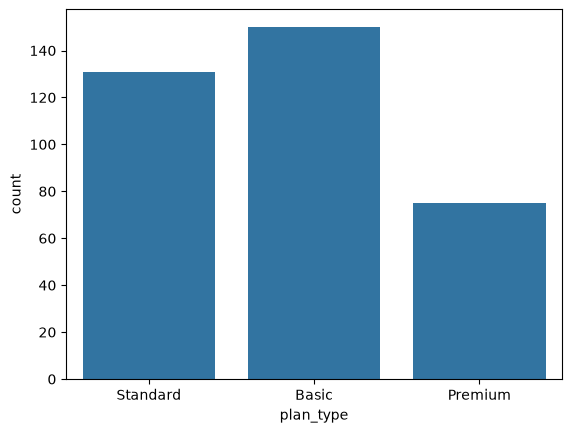

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x='plan_type')
plt.show()

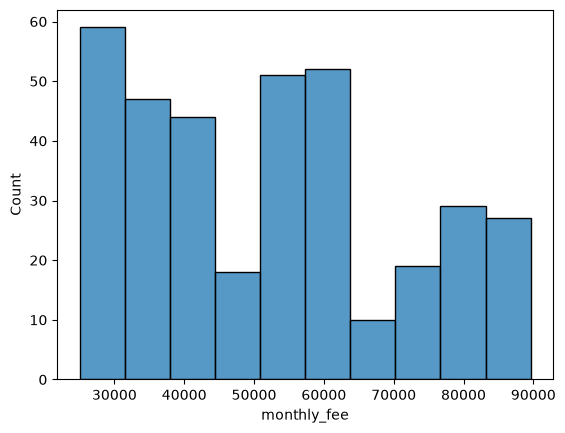

In [44]:
sns.histplot(data=df, x='monthly_fee')
plt.show()

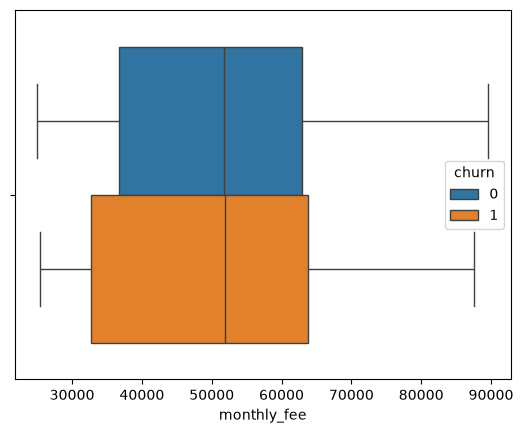

In [45]:
sns.boxplot(data=df, x='monthly_fee', hue='churn')
plt.show()

<Axes: >

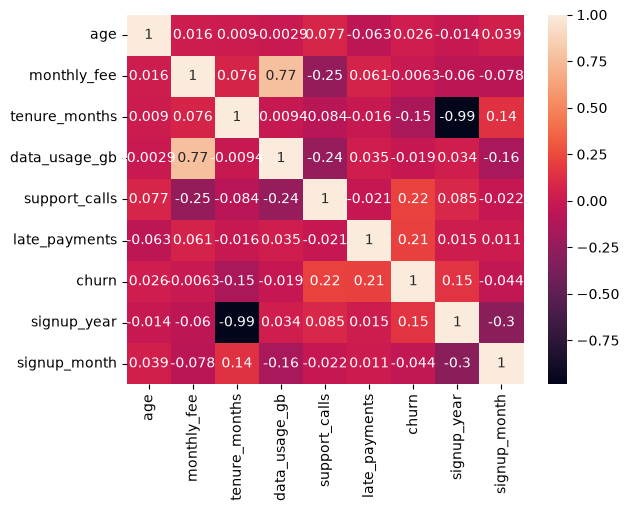

In [46]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True)

In [47]:
# 4. 범주형 데이터 처리
df['discount_applied'] = df['discount_applied'].map({
    'No':0,
    'Yes':1
})

# drop_first로 첫번째 컬럼을 제거하지만 , 있는 두 값이 모두 false면 자동으로 basic이라고 해석할 수 있음.
# 중복되는 더미 컬럼 하나를 제거한다
df = pd.get_dummies(df, columns=['payment_method'], drop_first=True, dtype=int)

In [48]:
df.head()

,age,region,plan_type,monthly_fee,tenure_months,data_usage_gb,support_calls,late_payments,device_type,discount_applied,churn,signup_year,signup_month,payment_method_BankTransfer,payment_method_Card,payment_method_MobilePay
0,59.0,Incheon,Standard,49908,38,42.1,7,1,iOS,1,0,2023,6,0,1,0
1,47.0,Daegu,Basic,37842,24,22.1,1,0,iOS,0,0,2024,8,1,0,0
2,60.0,Incheon,Basic,32371,10,28.5,3,0,iOS,0,0,2025,9,0,0,0
3,71.0,Busan,Standard,65875,4,34.0,3,0,iOS,0,0,2026,3,0,0,0
4,49.0,Incheon,Basic,33110,19,22.9,7,2,iOS,0,0,2024,12,0,0,0


In [49]:
df = pd.get_dummies(df, columns=['region', 'plan_type', 'device_type'], drop_first=True, dtype=int)

In [50]:
df.head()

,age,monthly_fee,tenure_months,data_usage_gb,support_calls,late_payments,discount_applied,churn,signup_year,signup_month,...,payment_method_Card,payment_method_MobilePay,region_Daegu,region_Daejeon,region_Incheon,region_Seoul,plan_type_Premium,plan_type_Standard,device_type_Other,device_type_iOS
0,59.0,49908,38,42.1,7,1,1,0,2023,6,...,1,0,0,0,1,0,0,1,0,1
1,47.0,37842,24,22.1,1,0,0,0,2024,8,...,0,0,1,0,0,0,0,0,0,1
2,60.0,32371,10,28.5,3,0,0,0,2025,9,...,0,0,0,0,1,0,0,0,0,1
3,71.0,65875,4,34.0,3,0,0,0,2026,3,...,0,0,0,0,0,0,0,1,0,1
4,49.0,33110,19,22.9,7,2,0,0,2024,12,...,0,0,0,0,1,0,0,0,0,1


In [51]:
# 5. 데이터 분할과 스케일링
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

x = df.drop(columns=['churn'])
y = df['churn']

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = RobustScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [52]:
# 모델 학습
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

model.fit(x_train_scaled, y_train)

pred = model.predict(x_test_scaled)

In [53]:
from sklearn.metrics import recall_score, accuracy_score, precision_score

print(model.classes_)

# 클래스가 1일 확률 추출
# roc-auc, 임계값 변경 시 사용
proba = model.predict_proba(x_test_scaled)[:,1]

[0 1]


In [54]:
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix
from sklearn.metrics import classification_report

print('acc : ', accuracy_score(y_test, pred))
print('prec : ', precision_score(y_test, pred))
print('recall : ', recall_score(y_test, pred))
print('f1 : ', f1_score(y_test, pred))
print('roc_auc : ', roc_auc_score(y_test, proba)) # roc-auc = proba 넣어야 함
print('conf : ', confusion_matrix(y_test, pred))
print('report : ', classification_report(y_test, pred))

acc :  0.5972222222222222
prec :  0.21875
recall :  0.6363636363636364
f1 :  0.32558139534883723
roc_auc :  0.6780923994038748
conf :  [[36 25]
 [ 4  7]]
report :                precision    recall  f1-score   support

           0       0.90      0.59      0.71        61
           1       0.22      0.64      0.33        11

    accuracy                           0.60        72
   macro avg       0.56      0.61      0.52        72
weighted avg       0.80      0.60      0.65        72



In [55]:
# 임계값 변경
pred_03 = (proba>=0.3).astype(int)

print('prec : ', precision_score(y_test, pred_03))
print('recall : ', recall_score(y_test, pred_03))
print('f1 : ', f1_score(y_test, pred_03))
print('conf : ', confusion_matrix(y_test, pred_03))

# 임계값을 낮췄을 때, 1을 잡는 능력은 올라갔으나, 0을 1이라고 잘못 판단하는 상황이 잦아져서 Precision이 상당히 떨어졌다.

prec :  0.20408163265306123
recall :  0.9090909090909091
f1 :  0.3333333333333333
conf :  [[22 39]
 [ 1 10]]
